# Vanishing-Act 🎩
### "Small-caps beat large-caps" — the factor that launched an industry, on the tape

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Survived publication?: Busted](https://img.shields.io/badge/Survived_publication%3F-Busted-8b949e?style=flat-square)

The size premium is finance's oldest factor: Banz showed in 1981 that small companies out-earn big ones, and a thousand small-cap funds followed. We test it on the longest free data — the Russell 2000 vs the S&P 500 back to 1987. Over 39 years the premium is **zero**, small-caps actually *trail* on a risk-adjusted basis, and since 2010 the effect has flipped sign.

> 📓 **Plain-language layer.** The t-stats and the sign reversal are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every chart is generated by the code beside it.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))  # repo root (quantlab/)
sys.path.insert(0, os.path.abspath(".."))        # study package (vanishing_act/)
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5); plt.rcParams["axes.grid"] = True
import numpy as np, pandas as pd
from vanishing_act import data, strategy as st
ret = data.fetch_pairs()                       # cache-first; built by examples/verify.py --fetch
smb_long = st.smb(ret, "^RUT", "^GSPC")        # the long-history spread


## The answer first 🎯

| The belief | The tape |
|---|---|
| "Small-caps earn a premium" | Russell 2000 − S&P 500 = **+0.1%/yr over 39 years** (t = 0.05). |
| "…for taking more risk" | Small-caps' **Sharpe is lower** (0.47 vs 0.61). |
| "A timeless factor" | Positive before 2010, **negative since.** |

## 1 · The claim

Banz (1981): the smallest stocks earn higher returns than the largest, even after adjusting for market risk — the **size premium**, the SMB factor in every textbook model, the rationale for small-cap allocations everywhere.

## 2 · So what?

If small beats big, every investor should tilt small. If the premium has decayed to nothing — or reversed — then a core piece of portfolio orthodoxy is anchored on a fact that stopped being true decades ago.

## 3 · How would we even know?

Take the longest free proxy — Russell 2000 minus S&P 500, 1987–2026 — measure the spread and its t-stat, compare each side's standalone Sharpe, and split the sample at 2010 to see whether the premium survived its own publication.

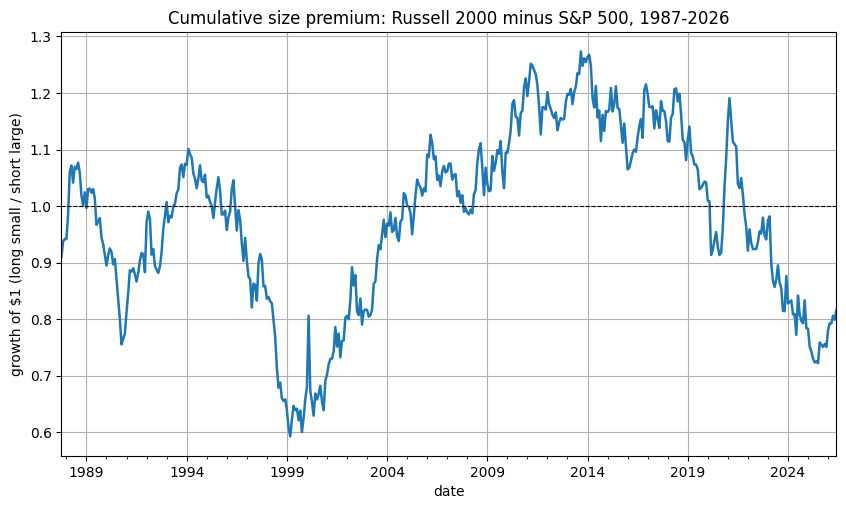

39-year SMB: +0.08%/yr, Sharpe 0.01, Lo t=0.05


In [2]:
eq=(1+smb_long).cumprod()
ax=eq.plot(title='Cumulative size premium: Russell 2000 minus S&P 500, 1987-2026',lw=1.8)
ax.axhline(1.0,color='k',lw=.8,ls='--'); ax.set_ylabel('growth of $1 (long small / short large)'); plt.show()
s=st.smb_stats(smb_long); print(f"39-year SMB: {s['mean_ann']:+.2%}/yr, Sharpe {s['sharpe']:.2f}, Lo t={s['tstat']:.2f}")

## 4 · The teardown

A line that wanders up in the 80s–90s and gives it all back. The decade split shows the turn.

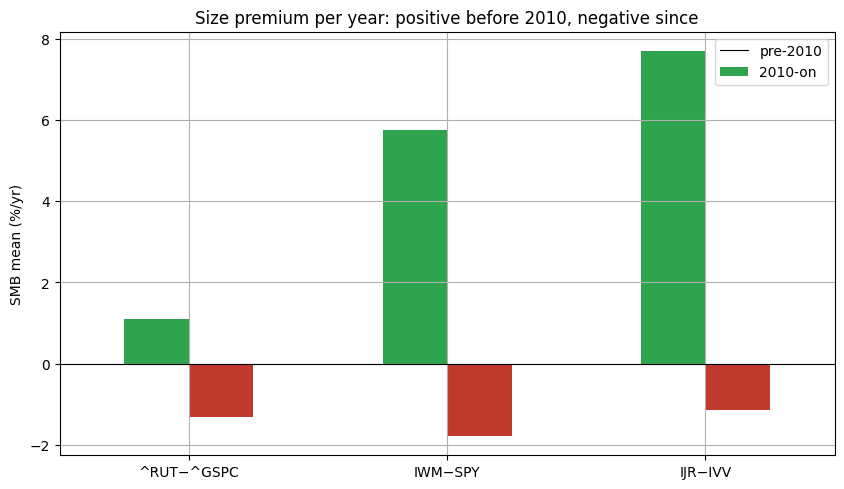

In [3]:
pairs={'^RUT−^GSPC':('^RUT','^GSPC'),'IWM−SPY':('IWM','SPY'),'IJR−IVV':('IJR','IVV')}
dec={k: st.decay_split(st.smb(ret,a,b))['mean_ann'] for k,(a,b) in pairs.items() if a in ret and b in ret}
D=pd.DataFrame(dec).T*100
ax=D.plot.bar(rot=0,color=['#2ea44f','#c0392b'],title='Size premium per year: positive before 2010, negative since')
ax.set_ylabel('SMB mean (%/yr)'); ax.axhline(0,color='k',lw=.8); ax.legend(['pre-2010','2010-on']); plt.show()

**Read it plainly.** Green before 2010, red after — on every pair. The premium didn't just shrink; it changed sign. That's what an arbitraged-away anomaly looks like.

## 5 · The verdict

**Signal: None** — zero over 39 years, small-caps even trailing on Sharpe. **Tradability: Mirage** — nothing to harvest. **Survived publication?: Busted** — the premium reversed after Banz.

## 6 · Could you actually trade it?

You can buy a small-cap ETF cheaply — but you'd be buying a *lower* Sharpe than the S&P 500, not a premium. The only version with a faint pulse (the S&P 600) earns it by screening for profitable companies — that's a quality bet, not a size one.

## 7 · Going further 🚪

The quants notebook adds the Lo t-stats and the quality caveat (Asness et al. 2018, *Size Matters, If You Control Your Junk*). This closes the five-study debunk bench from the [paperswithbacktest backlog](../../../docs/pwb_strategies_inventory.md).